In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducibility


### Problem 1: Portfolio Construction & Daily Returns

In [2]:
# --- 1a: Create prices_df and compute daily returns ---
prices_data = {
    'RELIANCE':    [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY':        [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK':    [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS':  [520,  535,  528,  540,  555,  548],
}
prices_df = pd.DataFrame(prices_data, index=[f'Day {i}' for i in range(1, 7)])
print("Prices DataFrame:")
print(prices_df)

returns = prices_df.pct_change().dropna()
print("\nDaily Percentage Returns:")
print(returns.round(4))


Prices DataFrame:
       RELIANCE  INFY  HDFCBANK  TATAMOTORS
Day 1      2800  1450      1600         520
Day 2      2850  1470      1580         535
Day 3      2830  1460      1610         528
Day 4      2900  1490      1625         540
Day 5      2880  1510      1615         555
Day 6      2950  1500      1640         548

Daily Percentage Returns:
       RELIANCE    INFY  HDFCBANK  TATAMOTORS
Day 2    0.0179  0.0138   -0.0125      0.0288
Day 3   -0.0070 -0.0068    0.0190     -0.0131
Day 4    0.0247  0.0205    0.0093      0.0227
Day 5   -0.0069  0.0134   -0.0062      0.0278
Day 6    0.0243 -0.0066    0.0155     -0.0126


Units Purchased on Day 1:
  RELIANCE: 89.2857 units
  INFY: 172.4138 units
  HDFCBANK: 156.2500 units
  TATAMOTORS: 480.7692 units

Daily Portfolio Value:
Day 1    1000000.00
Day 2    1011999.10
Day 3    1009811.36
Day 4    1029346.76
Day 5    1036658.36
Day 6    1041725.09
dtype: float64


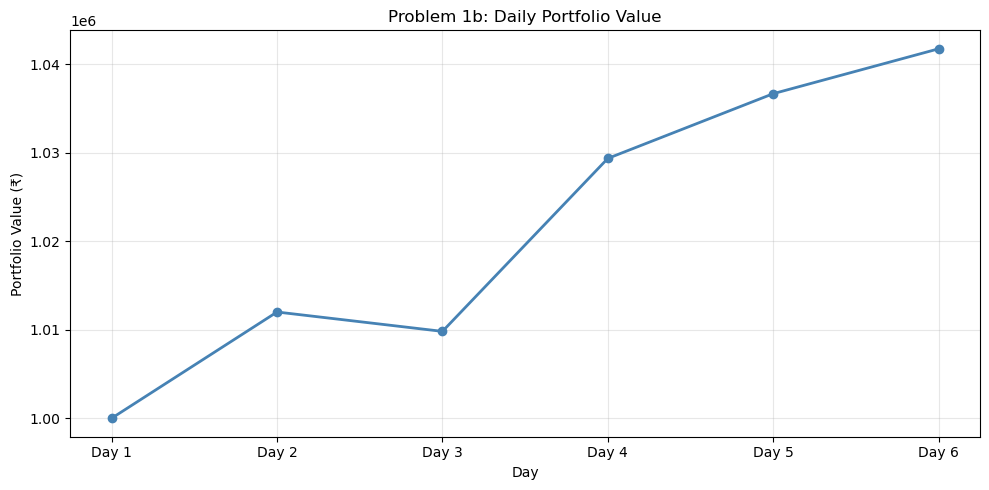

In [3]:
# --- 1b: Units purchased and daily portfolio value (vectorised) ---
initial_capital = 1_000_000
weights = np.array([0.25, 0.25, 0.25, 0.25])
allocation = initial_capital * weights
first_day_prices = prices_df.iloc[0]
units = allocation / first_day_prices

print("Units Purchased on Day 1:")
for asset, u in zip(prices_df.columns, units):
    print(f"  {asset}: {u:.4f} units")

# Vectorised: (T x N) . (N,) -> (T,)
portfolio_val = prices_df.dot(units)
print("\nDaily Portfolio Value:")
print(portfolio_val.round(2))

plt.figure(figsize=(10, 5))
plt.plot(portfolio_val.index, portfolio_val.values, marker='o', color='steelblue', linewidth=2)
plt.title('Problem 1b: Daily Portfolio Value')
plt.xlabel('Day'); plt.ylabel('Portfolio Value (₹)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [4]:
# --- 1c: Annualised volatility ---
portfolio_returns = portfolio_val.pct_change().dropna()
sigma_daily = portfolio_returns.std()
sigma_annual = sigma_daily * np.sqrt(252)
print(f"Daily σ     : {sigma_daily:.6f}")
print(f"Annual σ    : {sigma_annual:.4f}  ({sigma_annual*100:.2f}%)")


Daily σ     : 0.008034
Annual σ    : 0.1275  (12.75%)


### Problem 2: Risk Metrics — VaR, CVaR, and Drawdowns

In [5]:
# Extend to 50 simulated trading days
mu_sim, sigma_sim = 0.001, 0.015
synthetic_returns = np.random.normal(mu_sim, sigma_sim, 50)

V0 = portfolio_val.iloc[-1]
extended_values = [V0]
for r in synthetic_returns:
    extended_values.append(extended_values[-1] * (1 + r))
extended_values = np.array(extended_values)
R = np.diff(extended_values) / extended_values[:-1]

# --- 2a: Historical VaR ---
VaR_95 = -np.percentile(R, 5)
VaR_99 = -np.percentile(R, 1)
print(f"VaR 95%: {VaR_95*100:.4f}%  -> On 95% of days, loss will not exceed {VaR_95*100:.2f}%")
print(f"VaR 99%: {VaR_99*100:.4f}%  -> On 99% of days, loss will not exceed {VaR_99*100:.2f}%")


VaR 95%: 2.5188%  -> On 95% of days, loss will not exceed 2.52%
VaR 99%: 2.8054%  -> On 99% of days, loss will not exceed 2.81%


In [6]:
# --- 2b: CVaR ---
CVaR_95 = -R[R < -VaR_95].mean()
CVaR_99 = -R[R < -VaR_99].mean()
print(f"CVaR 95%: {CVaR_95*100:.4f}%")
print(f"CVaR 99%: {CVaR_99*100:.4f}%")
print("CVaR is more informative: it captures the average loss in the tail, not just the cutoff.")


CVaR 95%: 2.7180%
CVaR 99%: 2.8395%
CVaR is more informative: it captures the average loss in the tail, not just the cutoff.


Max Drawdown: 18.1649%


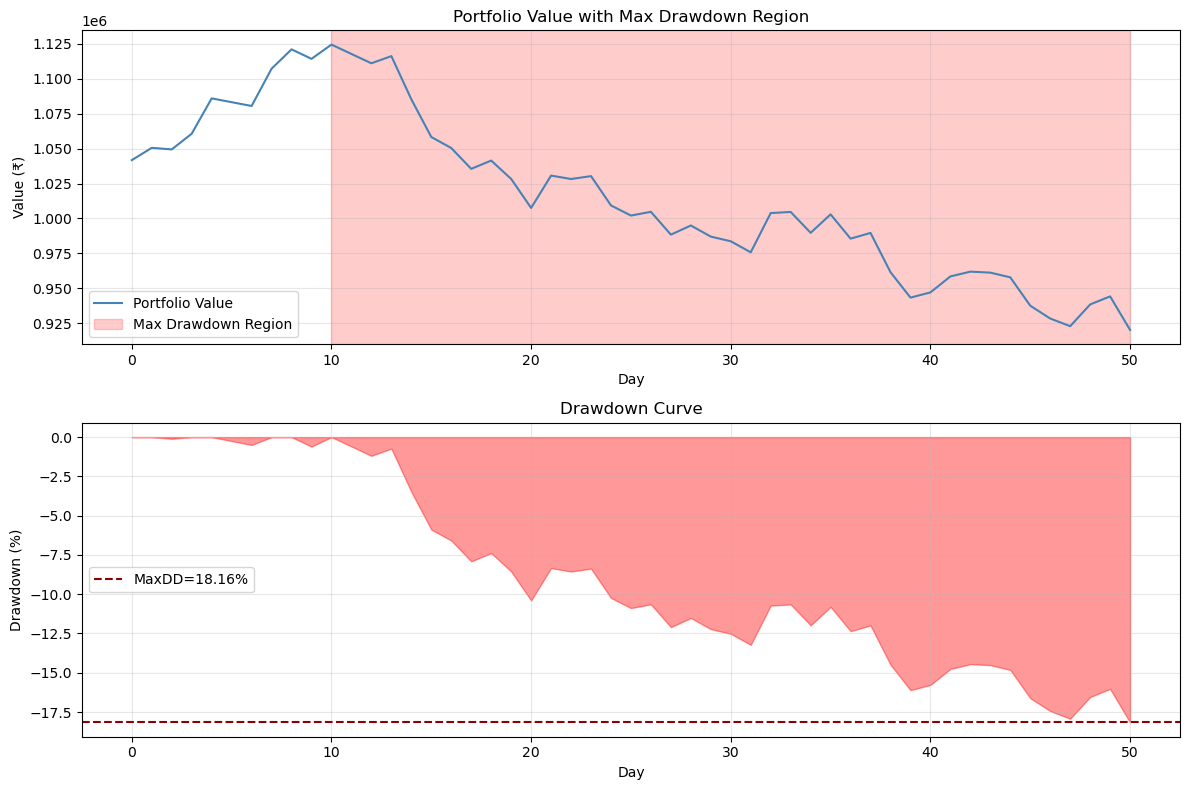

In [7]:
# --- 2c: Maximum Drawdown ---
running_peak = np.maximum.accumulate(extended_values)
drawdown = (running_peak - extended_values) / running_peak
MaxDD = drawdown.max()
MaxDD_idx = drawdown.argmax()
peak_idx = np.argmax(extended_values[:MaxDD_idx + 1])
print(f"Max Drawdown: {MaxDD*100:.4f}%")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(extended_values, color='steelblue', linewidth=1.5, label='Portfolio Value')
axes[0].axvspan(peak_idx, MaxDD_idx, alpha=0.2, color='red', label='Max Drawdown Region')
axes[0].set_title('Portfolio Value with Max Drawdown Region')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Value (₹)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].fill_between(range(len(drawdown)), -drawdown*100, 0, color='red', alpha=0.4)
axes[1].axhline(-MaxDD*100, color='darkred', linestyle='--', label=f'MaxDD={MaxDD*100:.2f}%')
axes[1].set_title('Drawdown Curve'); axes[1].set_xlabel('Day'); axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### Problem 3: Risk-Adjusted Performance Metrics

In [8]:
# 252 days of synthetic returns
returns_252 = np.random.normal(0.001, 0.015, 252)
Rf_annual = 0.06

# --- 3a: Sharpe Ratio ---
Rp_annual = returns_252.mean() * 252
sigma_annual_252 = returns_252.std() * np.sqrt(252)
Sharpe = (Rp_annual - Rf_annual) / sigma_annual_252
print(f"Annualised Return    : {Rp_annual*100:.4f}%")
print(f"Annualised Volatility: {sigma_annual_252*100:.4f}%")
print(f"Sharpe Ratio         : {Sharpe:.4f}")


Annualised Return    : 37.5299%
Annualised Volatility: 23.4839%
Sharpe Ratio         : 1.3426


In [9]:
# --- 3b: Sortino Ratio ---
downside = returns_252[returns_252 < 0]
sigma_d = np.sqrt(np.mean(downside**2)) * np.sqrt(252)
Sortino = (Rp_annual - Rf_annual) / sigma_d
print(f"Downside Deviation (annual): {sigma_d*100:.4f}%")
print(f"Sortino Ratio              : {Sortino:.4f}")
print("Sortino is higher than Sharpe when upside volatility is present,")
print("because σ_d ignores positive deviations from zero.")


Downside Deviation (annual): 22.4364%
Sortino Ratio              : 1.4053
Sortino is higher than Sharpe when upside volatility is present,
because σ_d ignores positive deviations from zero.


In [10]:
# --- 3c: Comparison ---
comparison = pd.DataFrame({
    'Metric': ['Sharpe Ratio', 'Sortino Ratio'],
    'Value': [round(Sharpe, 4), round(Sortino, 4)],
    'Volatility Used': ['Total σ', 'Downside σ only'],
    'Better For': ['Symmetric strategies', 'Asymmetric/momentum strategies']
})
print(comparison.to_string(index=False))


       Metric  Value Volatility Used                     Better For
 Sharpe Ratio 1.3426         Total σ           Symmetric strategies
Sortino Ratio 1.4053 Downside σ only Asymmetric/momentum strategies


### Problem 4: Backtesting a Simple Moving Average Strategy

In [11]:
# Generate 200-day random walk
P0 = 1000
eps = np.random.normal(0.001, 0.018, 200)
prices_rw = pd.Series([P0 * np.prod(1 + eps[:i]) if i > 0 else P0 for i in range(200)])

# --- 4a: SMA Crossover Signal ---
sma10 = prices_rw.rolling(10).mean()
sma30 = prices_rw.rolling(30).mean()
signal = pd.Series(0, index=prices_rw.index)
signal[sma10 > sma30] = 1
signal[sma10 < sma30] = -1
print(f"Signal counts: {signal.value_counts().to_dict()}")


Signal counts: {1: 109, -1: 62, 0: 29}


Final Strategy Value : ₹87,341.37
Final Buy-Hold Value : ₹135,147.97


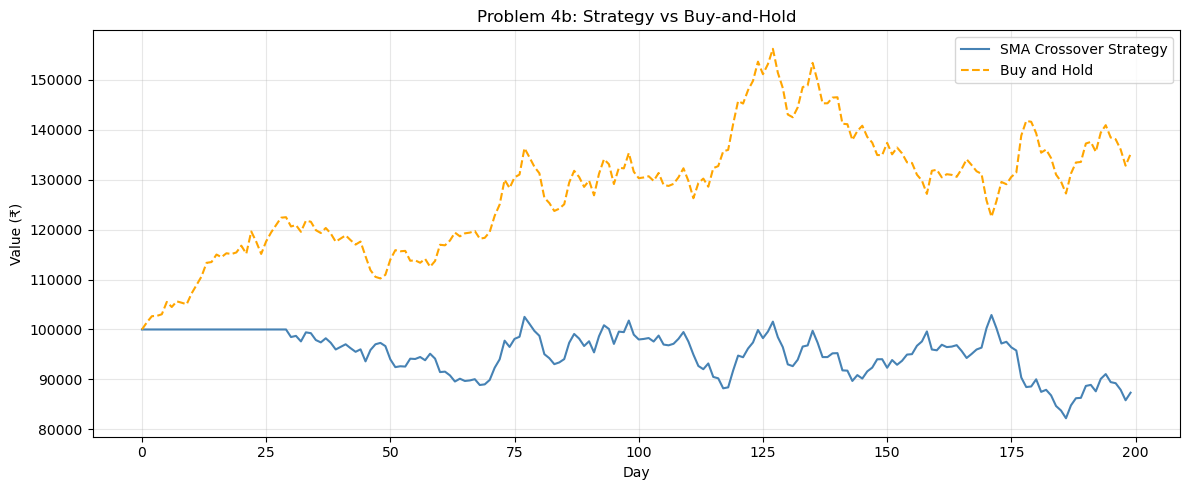

In [12]:
# --- 4b: Simulate & compare to buy-and-hold ---
initial_cap = 100_000
daily_ret = prices_rw.pct_change().fillna(0)
strategy_ret = signal.shift(1).fillna(0) * daily_ret
cum_strat = (1 + strategy_ret).cumprod() * initial_cap
cum_bh    = (1 + daily_ret).cumprod() * initial_cap

print(f"Final Strategy Value : ₹{cum_strat.iloc[-1]:,.2f}")
print(f"Final Buy-Hold Value : ₹{cum_bh.iloc[-1]:,.2f}")

plt.figure(figsize=(12, 5))
plt.plot(cum_strat, label='SMA Crossover Strategy', color='steelblue')
plt.plot(cum_bh, label='Buy and Hold', color='orange', linestyle='--')
plt.title('Problem 4b: Strategy vs Buy-and-Hold')
plt.xlabel('Day'); plt.ylabel('Value (₹)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [13]:
# --- 4c: Win Rate & Profit Factor ---
trade_ret = strategy_ret[strategy_ret != 0]
winning   = trade_ret[trade_ret > 0]
losing    = trade_ret[trade_ret < 0]
win_rate  = len(winning) / len(trade_ret)
pf        = winning.sum() / abs(losing.sum())
print(f"Win Rate     : {win_rate*100:.2f}%")
print(f"Profit Factor: {pf:.4f}")
print("PF > 1 does NOT guarantee a good strategy — it ignores drawdown profile,")
print("timing of losses, and capital at risk at any given time.")


Win Rate     : 51.76%
Profit Factor: 0.9164
PF > 1 does NOT guarantee a good strategy — it ignores drawdown profile,
timing of losses, and capital at risk at any given time.


### Problem 5: Feature Engineering

In [14]:
# Generate 300-day price series
n = 300
prices_feat = pd.Series([500 * np.prod(1 + np.random.normal(0.001, 0.018, i)) if i > 0 else 500
                         for i in range(n)], name='Price')

# --- 5a: Engineer features (no loops) ---
df = pd.DataFrame({'Price': prices_feat})
df['Return_1d']     = df['Price'].pct_change()
df['SMA_5']         = df['Price'].rolling(5).mean()
df['SMA_20']        = df['Price'].rolling(20).mean()
df['Volatility_10'] = df['Return_1d'].rolling(10).std()
df['Momentum_5']    = df['Price'] - df['Price'].shift(5)
df.dropna(inplace=True); df.reset_index(drop=True, inplace=True)
print(f"Shape: {df.shape}"); print(df.head())


Shape: (281, 6)
        Price  Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5
0  514.498156   0.083005  505.851400  499.115062       0.043392  -20.872857
1  484.082681  -0.059117  497.675546  498.319196       0.047220  -40.879271
2  486.679266   0.005364  490.349298  498.257515       0.047310  -36.631239
3  457.534776  -0.059884  483.572047  496.126688       0.050376  -33.886258
4  591.807350   0.293470  506.920446  501.508444       0.106971  116.741995


Class balance:
Target
1    141
0    140
Name: count, dtype: int64


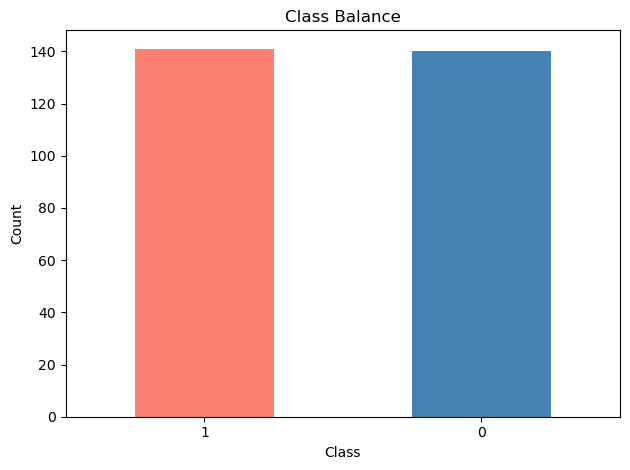

In [15]:
# --- 5b: Binary target ---
df['Target'] = (df['Return_1d'].shift(-1) > 0).astype(int)
df.dropna(inplace=True); df.reset_index(drop=True, inplace=True)
balance = df['Target'].value_counts()
print(f"Class balance:\n{balance}")
balance.plot(kind='bar', color=['salmon','steelblue'], title='Class Balance')
plt.xlabel('Class'); plt.ylabel('Count'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


In [16]:
# --- 5c: Min-Max normalisation ---
feature_cols = ['Return_1d','SMA_5','SMA_20','Volatility_10','Momentum_5']
X_raw = df[feature_cols].values
y_all = df['Target'].values
X_min, X_max = X_raw.min(axis=0), X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)
print(f"Scaled shape: {X_scaled.shape}")
print("Feature scaling is critical: without it, high-magnitude features like SMA_5 (in ₹)")
print("dominate distance computation over small-magnitude features like Return_1d.")


Scaled shape: (281, 5)
Feature scaling is critical: without it, high-magnitude features like SMA_5 (in ₹)
dominate distance computation over small-magnitude features like Return_1d.


### Problem 6: KNN Classifier From Scratch

In [17]:
# --- 6a: KNN implementation ---
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def knn_predict(X_train, y_train, X_test, k):
    preds = []
    for xq in X_test:
        dists = [euclidean_distance(xq, xt) for xt in X_train]
        k_idx = np.argsort(dists)[:k]
        k_labels = y_train[k_idx]
        preds.append(np.bincount(k_labels.astype(int)).argmax())
    return np.array(preds)


k= 3  Accuracy: 66.67%
k= 5  Accuracy: 70.18%
k= 7  Accuracy: 66.67%
k=11  Accuracy: 66.67%
k=15  Accuracy: 70.18%

Optimal k: 5  (70.18%)


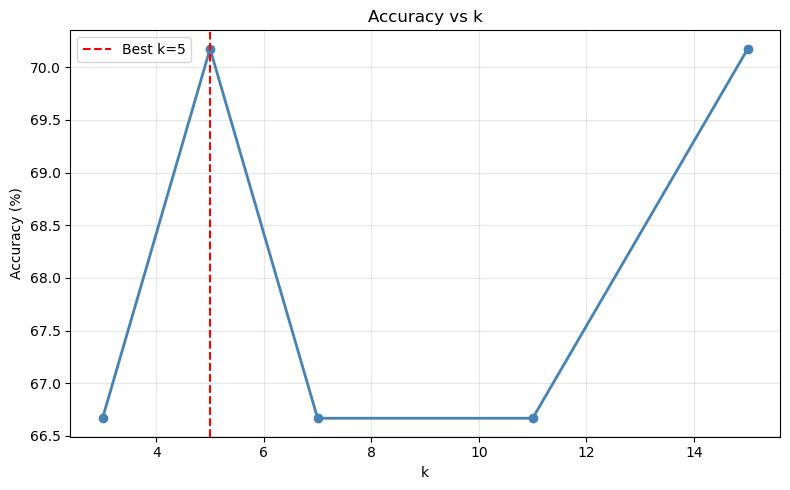

In [18]:
# --- 6b: Evaluate k values ---
split = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_all[:split], y_all[split:]

k_values = [3, 5, 7, 11, 15]
accuracies = []
for k in k_values:
    y_pred = knn_predict(X_train, y_train, X_test, k)
    acc = np.mean(y_pred == y_test)
    accuracies.append(acc)
    print(f"k={k:2d}  Accuracy: {acc*100:.2f}%")

best_k = k_values[np.argmax(accuracies)]
print(f"\nOptimal k: {best_k}  ({max(accuracies)*100:.2f}%)")

plt.figure(figsize=(8,5))
plt.plot(k_values, [a*100 for a in accuracies], marker='o', color='steelblue', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.title('Accuracy vs k'); plt.xlabel('k'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [19]:
# --- 6c: Confusion Matrix ---
y_pred_best = knn_predict(X_train, y_train, X_test, best_k)
TP = np.sum((y_pred_best==1)&(y_test==1))
FP = np.sum((y_pred_best==1)&(y_test==0))
TN = np.sum((y_pred_best==0)&(y_test==0))
FN = np.sum((y_pred_best==0)&(y_test==1))
Precision = TP/(TP+FP) if (TP+FP)>0 else 0
Recall    = TP/(TP+FN) if (TP+FN)>0 else 0
print(f"TP={TP}, FP={FP}, TN={TN}, FN={FN}")
print(f"Precision: {Precision:.4f}   Recall: {Recall:.4f}")
print("\nPrecision is more important when false positives are costly.")
print("FP = predicting a price rise that doesn't happen = entering a bad trade.")
print("We prefer fewer, more reliable buy signals over capturing every upward move.")


TP=19, FP=7, TN=21, FN=10
Precision: 0.7308   Recall: 0.6552

Precision is more important when false positives are costly.
FP = predicting a price rise that doesn't happen = entering a bad trade.
We prefer fewer, more reliable buy signals over capturing every upward move.


### Problem 7: Linear Regression From Scratch

In [20]:
# Continuous target: next-day return
y_reg = df['Return_1d'].shift(-1).dropna().values
X_reg = X_scaled[:len(y_reg)]
split_r = int(0.8 * len(X_reg))
X_tr, X_te = X_reg[:split_r], X_reg[split_r:]
y_tr, y_te = y_reg[:split_r], y_reg[split_r:]

# --- 7a: Normal Equation ---
X_tr_b = np.hstack([np.ones((X_tr.shape[0],1)), X_tr])
X_te_b = np.hstack([np.ones((X_te.shape[0],1)), X_te])
beta = np.linalg.inv(X_tr_b.T @ X_tr_b) @ X_tr_b.T @ y_tr

print("Normal Equation Coefficients:")
for name, coef in zip(['Bias']+feature_cols, beta):
    print(f"  {name:15s}: {coef:+.6f}  ({'positive' if coef>0 else 'negative'})")


Normal Equation Coefficients:
  Bias           : +0.705042  (positive)
  Return_1d      : -1.041009  (negative)
  SMA_5          : -0.712765  (negative)
  SMA_20         : +0.052690  (positive)
  Volatility_10  : +0.443918  (positive)
  Momentum_5     : -0.633884  (negative)


MSE: 0.20360619
R² : 0.100065


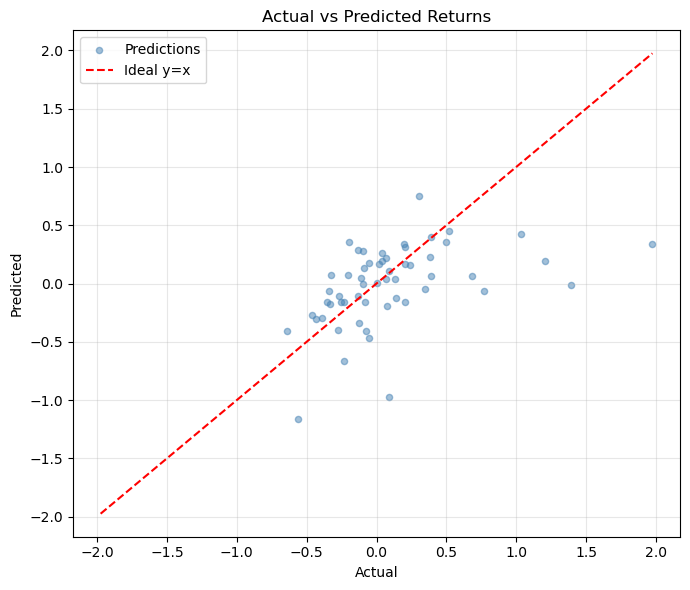

In [21]:
# --- 7b: MSE and R² ---
y_pred_reg = X_te_b @ beta
MSE = np.mean((y_te - y_pred_reg)**2)
R2  = 1 - np.sum((y_te - y_pred_reg)**2) / np.sum((y_te - y_te.mean())**2)
print(f"MSE: {MSE:.8f}")
print(f"R² : {R2:.6f}")

plt.figure(figsize=(7,6))
plt.scatter(y_te, y_pred_reg, alpha=0.5, color='steelblue', s=20, label='Predictions')
lim = max(abs(y_te).max(), abs(y_pred_reg).max())
plt.plot([-lim,lim],[-lim,lim],'r--',label='Ideal y=x')
plt.title('Actual vs Predicted Returns'); plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


Coefficient comparison (Normal Eq vs Gradient Descent):
  Bias           : NE=+0.705042  GD=+0.122843
  Return_1d      : NE=-1.041009  GD=-0.147654
  SMA_5          : NE=-0.712765  GD=-0.043475
  SMA_20         : NE=+0.052690  GD=+0.003623
  Volatility_10  : NE=+0.443918  GD=+0.060416
  Momentum_5     : NE=-0.633884  GD=-0.105754
No. The coefficients obtained using Batch Gradient Descent did not converge  to the Normal Equation solution.


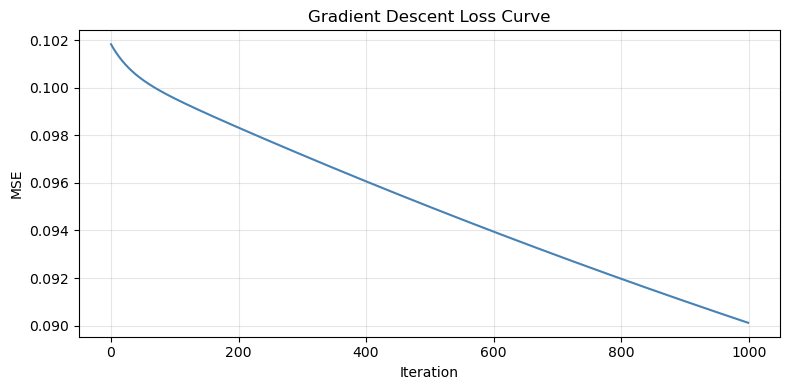

In [22]:
# --- 7c: Gradient Descent ---
eta, n_iter = 0.01, 1000
beta_gd = np.zeros(X_tr_b.shape[1])
loss_curve = []
for _ in range(n_iter):
    res = X_tr_b @ beta_gd - y_tr
    beta_gd -= eta * (X_tr_b.T @ res) / len(y_tr)
    loss_curve.append(np.mean(res**2))

print("Coefficient comparison (Normal Eq vs Gradient Descent):")
for name, ne, gd in zip(['Bias']+feature_cols, beta, beta_gd):
    print(f"  {name:15s}: NE={ne:+.6f}  GD={gd:+.6f}")
print("No. The coefficients obtained using Batch Gradient Descent did not converge  to the Normal Equation solution.")
plt.figure(figsize=(8,4))
plt.plot(loss_curve, color='steelblue', linewidth=1.5)
plt.title('Gradient Descent Loss Curve'); plt.xlabel('Iteration'); plt.ylabel('MSE')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


### Problem 8: Portfolio Allocation with Linear Regression

Synthetic prices (first 5 rows):
      RELIANCE         INFY     HDFCBANK  TATAMOTORS
0  2853.372181  1457.536374  1617.467683  527.123207
1  2865.037799  1452.421017  1617.225412  525.146421
2  2873.972357  1463.682158  1627.613723  534.232661
3  2935.545138  1492.261275  1672.124071  547.499499
4  2946.765541  1488.874301  1663.110503  551.805037

Total days: 252

Predicted expected returns (out-of-sample, last test point):
  RELIANCE    : 0.0988%
  INFY        : 0.0220%
  HDFCBANK    : 0.5813%
  TATAMOTORS  : 0.4238%

ML-driven weights:
  RELIANCE    : 8.77%
  INFY        : 1.96%
  HDFCBANK    : 51.63%
  TATAMOTORS  : 37.64%
  Sum: 1.0000


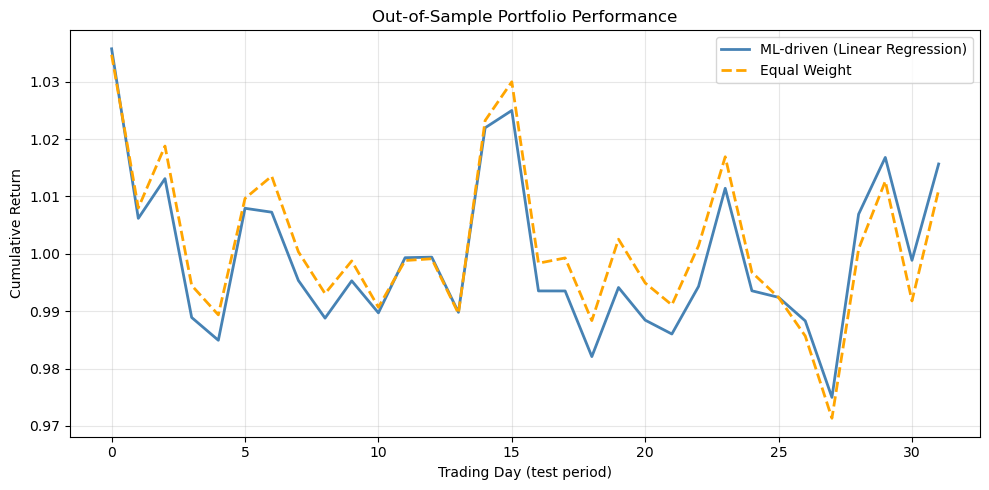


Final cumulative return – ML-driven: 1.56%
Final cumulative return – Equal weight: 1.11%

Limitation: Linear regression assumes stationarity. Financial returns exhibit
regime changes and non-linearity, making in-sample predictions unreliable out-of-sample.
Even with synthetic data, the model may fail when the market regime shifts.


In [23]:
# =============================================================================
# Problem 8: Portfolio Allocation with Linear Regression (Corrected)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducibility

# -----------------------------------------------------------------------------
# 1. Generate a consistent synthetic market for all assets
# -----------------------------------------------------------------------------
n_days = 252
mu, sigma = 0.001, 0.015
market_returns = np.random.normal(mu, sigma, n_days)

idio_vol = 0.005

initial_prices = {
    'RELIANCE': 2800,
    'INFY': 1450,
    'HDFCBANK': 1600,
    'TATAMOTORS': 520
}
assets = list(initial_prices.keys())

prices = {}
for asset, p0 in initial_prices.items():
    eps = np.random.normal(0, idio_vol, n_days)
    total_returns = market_returns + eps
    prices[asset] = p0 * np.cumprod(1 + total_returns)

prices_df = pd.DataFrame(prices)
print("Synthetic prices (first 5 rows):")
print(prices_df.head())
print(f"\nTotal days: {len(prices_df)}")

# -----------------------------------------------------------------------------
# 2. Feature engineering (same as Problem 5/7)
# -----------------------------------------------------------------------------
def engineer_features(price_series):
    df = pd.DataFrame({'Price': price_series})
    df['Return_1d'] = df['Price'].pct_change()
    df['SMA_5'] = df['Price'].rolling(5).mean()
    df['SMA_20'] = df['Price'].rolling(20).mean()
    df['Volatility_10'] = df['Return_1d'].rolling(10).std()
    df['Momentum_5'] = df['Price'] - df['Price'].shift(5)
    df.dropna(inplace=True)
    return df

feature_cols = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']

# -----------------------------------------------------------------------------
# 3. Train linear regression (Normal Equation) for each asset
#    Use first 80% for training, predict last 20% out-of-sample
# -----------------------------------------------------------------------------
split_ratio = 0.8
split_idx = int(n_days * split_ratio)

predictions = []   # will hold predicted next-day returns for the last test point

for asset in assets:
    df = engineer_features(prices[asset])
    X_raw = df[feature_cols].values
    y_raw = df['Return_1d'].shift(-1).dropna().values
    X_raw = X_raw[:len(y_raw)]
    
    # Min-Max scaling
    X_min = X_raw.min(axis=0)
    X_max = X_raw.max(axis=0)
    X_scaled = (X_raw - X_min) / (X_max - X_min + 1e-12)
    
    # Train/test split
    X_train = X_scaled[:split_idx]
    y_train = y_raw[:split_idx]
    X_test  = X_scaled[split_idx:]
    
    # Add bias column
    X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
    X_test_b  = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
    
    # Normal equation: β = (XᵀX)⁻¹ Xᵀ y
    beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
    
    # Predict the next-day return for the last test point
    # FIXED: using .item() instead of float() to avoid deprecation warning
    pred = (X_test_b[-1:] @ beta).item()
    predictions.append(pred)

predictions = np.array(predictions)

print("\nPredicted expected returns (out-of-sample, last test point):")
for asset, p in zip(assets, predictions):
    print(f"  {asset:12s}: {p*100:.4f}%")

# -----------------------------------------------------------------------------
# 4. Portfolio weights: proportional to positive predictions
# -----------------------------------------------------------------------------
pos = np.maximum(predictions, 0)
if pos.sum() > 0:
    ml_weights = pos / pos.sum()
else:
    ml_weights = np.ones(len(assets)) / len(assets)

print("\nML-driven weights:")
for asset, w in zip(assets, ml_weights):
    print(f"  {asset:12s}: {w*100:.2f}%")
print(f"  Sum: {ml_weights.sum():.4f}")

# -----------------------------------------------------------------------------
# 5. Backtest on the same out-of-sample period
# -----------------------------------------------------------------------------
# Collect test returns for each asset
test_returns = {}
for asset in assets:
    df = engineer_features(prices[asset])
    rets = df['Return_1d'].values[split_idx:]
    test_returns[asset] = rets

test_days = len(test_returns[assets[0]])

eq_returns = np.zeros(test_days)
ml_returns = np.zeros(test_days)

for d in range(test_days):
    daily_ret = np.array([test_returns[a][d] for a in assets])
    eq_returns[d] = np.mean(daily_ret)
    ml_returns[d] = ml_weights @ daily_ret

# Cumulative returns
cum_eq = np.cumprod(1 + eq_returns)
cum_ml = np.cumprod(1 + ml_returns)

plt.figure(figsize=(10,5))
plt.plot(cum_ml, label='ML-driven (Linear Regression)', linewidth=2, color='steelblue')
plt.plot(cum_eq, label='Equal Weight', linewidth=2, color='orange', linestyle='--')
plt.title('Out-of-Sample Portfolio Performance')
plt.xlabel('Trading Day (test period)')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal cumulative return – ML-driven: {cum_ml[-1]-1:.2%}")
print(f"Final cumulative return – Equal weight: {cum_eq[-1]-1:.2%}")

# -----------------------------------------------------------------------------
# 6. Discuss limitation
# -----------------------------------------------------------------------------
print("\nLimitation: Linear regression assumes stationarity. Financial returns exhibit")
print("regime changes and non-linearity, making in-sample predictions unreliable out-of-sample.")
print("Even with synthetic data, the model may fail when the market regime shifts.")

### Problem 9: Model Comparison & Hyperparameter Tuning

In [24]:
# --- 9a: 5-Fold CV ---
def k_fold_cv(X, y, k_folds, k_knn):
    n, fold_size = len(X), len(X)//k_folds
    accs = []
    for fold in range(k_folds):
        vs, ve = fold*fold_size, (fold+1)*fold_size
        X_val, y_val = X[vs:ve], y[vs:ve]
        X_tr2 = np.concatenate([X[:vs], X[ve:]])
        y_tr2 = np.concatenate([y[:vs], y[ve:]])
        accs.append(np.mean(knn_predict(X_tr2,y_tr2,X_val,k_knn) == y_val))
    return np.array(accs)

cv_results = {}
for k_knn in [3, 7, 11]:
    accs = k_fold_cv(X_scaled, y_all, 5, k_knn)
    cv_results[k_knn] = accs
    print(f"k={k_knn}: Mean={accs.mean()*100:.2f}%  Std={accs.std()*100:.2f}%")


k=3: Mean=47.83%  Std=3.64%
k=7: Mean=48.70%  Std=6.39%
k=11: Mean=46.96%  Std=4.48%


In [25]:
# --- 9b: Summary table ---
best_knn_k = max(cv_results, key=lambda k: cv_results[k].mean())
summary = pd.DataFrame({
    'Model':       ['KNN Classifier', 'Linear Regression'],
    'Accuracy/R²': [f"{cv_results[best_knn_k].mean()*100:.2f}%", f"{R2:.4f}"],
    'MSE/N.A.':    ['N/A', f"{MSE:.6f}"],
    'Best Param':  [f"k={best_knn_k}", 'η=0.01, 1000 iter']
})
print(summary.to_string(index=False))


            Model Accuracy/R² MSE/N.A.        Best Param
   KNN Classifier      48.70%      N/A               k=7
Linear Regression      0.1001 0.203606 η=0.01, 1000 iter


# --- 9c: Discussion ---

I would deploy KNN for direction prediction (classification task).
Linear Regression for return magnitude estimation.

Two risks of deploying ML in live trading:
1. Overfitting: model memorises training noise, fails on live data.
   Mitigation: walk-forward cross-validation, regularisation.
2. Look-ahead bias: future data leaks into features during construction.
   Mitigation: strictly enforce point-in-time feature computation.



Problem 10a — Diversification:
Portfolio variance: σ²_p = Σ w²_i σ²_i + Σ_{i not equal to j} w_i w_j σ_i σ_j ρ_ij
The cross terms are reduced when ρ_ij is low or negative. At ρ_ij = -1
(perfect negative correlation), cross terms become negative, potentially
reducing σ²_p below any individual asset's variance. This lowers risk
without reducing expected return — the free lunch.

Problem 10b — Fundamental Feature:
Earnings Yield = EPS / Price (inverse P/E). Obtainable from BSE/NSE filings
or Yahoo Finance API. Merge with technical features on date, normalise, feed
into KNN feature vector.

Problem 10c — Curse of Dimensionality:
As dimensions grow, all pairwise distances converge — "nearest" loses meaning.
KNN performance degrades in high-dimensional financial data. Mitigation: PCA
to reduce to top-k components explaining most variance before applying KNN.

Problem 10d — Overfitting in Backtesting (Sharpe 3.5 - 0.4 live):
1. Look-ahead bias: future data in features. Detection: walk-forward validation.
2. Data snooping: testing many param combos, picking best. Detection: holdout set.
3. Survivorship bias: only testing on surviving stocks. Detection: point-in-time data.

Problem 10e — Linear Regression Violations in Finance:
1. Autocorrelation: return residuals are serially correlated (momentum/mean-reversion).
   OLS standard errors are underestimated → misleadingly significant coefficients.
2. Heteroscedasticity: variance clusters (ARCH/GARCH effects).
   OLS over-weights high-volatility periods, distorting coefficient estimates.


